In [4]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 1. Chargement
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = maligne, 1 = bénigne

print(f"Shape: {X.shape}, Cibles uniques: {np.unique(y)}")
print(f"Valeurs manquantes: {X.isnull().sum().sum()}")

# 2. Séparation Train / Val / Test (70% / 15% / 15%)
# stratify=y préserve la répartition des classes
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 3. Normalisation (CRUCIAL pour un MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# 4. Conversion en tenseurs PyTorch
# Pour BCEWithLogitsLoss, la cible doit être de forme (N, 1) et float
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 5. Création des DataLoaders
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Données prêtes. | Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}")

Shape: (569, 30), Cibles uniques: [0 1]
Valeurs manquantes: 0
✅ Données prêtes. | Train: 13 batches, Val: 3, Test: 3


In [5]:
import torch
import torch.nn as nn
import os

# 1. Gestion du device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device détecté: {device}")

# Dimensions du dataset
input_dim = X_train_t.shape[1]   # 30 features
hidden_dim = 64
output_dim = 1                   # Classification binaire

# ---------------------------------------------------------
# 2. Version 1: nn.Sequential
# ---------------------------------------------------------
mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim // 2),
    nn.ReLU(),
    nn.Linear(hidden_dim // 2, output_dim)
).to(device)

print("✅ [v1] MLP Sequential créé.")

# ---------------------------------------------------------
# 3. Version 2: Classe personnalisée nn.Module
# ---------------------------------------------------------
class MLPCustom(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPCustom, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()
        # Pas d'activation sur la dernière couche car on utilisera BCEWithLogitsLoss

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Logits bruts
        return x

mlp_custom = MLPCustom(input_dim, hidden_dim, output_dim).to(device)
print("✅ [v2] MLP Custom créé.")

# ---------------------------------------------------------
# 4. Inspection des paramètres (Exigé dans le sujet)
# ---------------------------------------------------------
print("\n🔍 named_parameters() - MLP Custom:")
for name, param in mlp_custom.named_parameters():
    print(f"  {name:15s} | shape: {str(param.shape):12s} | grad: {param.requires_grad}")

print("\n💾 state_dict() - Clés disponibles:")
print(f"  {list(mlp_custom.state_dict().keys())}")

# ---------------------------------------------------------
# 5. Fonction d'initialisation (3 stratégies demandées)
# ---------------------------------------------------------
def apply_initialization(model, strategy="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == "gaussian":
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 0.0)
            elif strategy == "constant":
                nn.init.constant_(m.weight, 0.01)
                nn.init.constant_(m.bias, 0.0)
            elif strategy == "xavier":
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

# Test rapide de la propagation avant pour valider la cohérence des shapes
test_batch = X_train_t[:5].to(device)
logits = mlp_custom(test_batch)
print(f"\n✅ Forward pass OK. Shape logits: {logits.shape} (attendu: torch.Size([5, 1]))")

# ---------------------------------------------------------
# 6. Sauvegarde & Rechargement
# ---------------------------------------------------------
SAVE_PATH = "best_mlp_part1.pth"

# Sauvegarde
torch.save(mlp_custom.state_dict(), SAVE_PATH)
print(f"💾 Modèle sauvegardé dans: {SAVE_PATH}")

# Rechargement (simulation)
mlp_reloaded = MLPCustom(input_dim, hidden_dim, output_dim).to(device)
mlp_reloaded.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print("📥 Modèle rechargé avec succès. Vérification de cohérence...")

# Vérification que les poids sont identiques après rechargement
for p1, p2 in zip(mlp_custom.parameters(), mlp_reloaded.parameters()):
    assert torch.allclose(p1, p2), "❌ Erreur: les poids ne correspondent pas !"
print("✅ Cohérence CPU/GPU & state_dict validée.")

🖥️ Device détecté: cpu
✅ [v1] MLP Sequential créé.
✅ [v2] MLP Custom créé.

🔍 named_parameters() - MLP Custom:
  fc1.weight      | shape: torch.Size([64, 30]) | grad: True
  fc1.bias        | shape: torch.Size([64]) | grad: True
  fc2.weight      | shape: torch.Size([32, 64]) | grad: True
  fc2.bias        | shape: torch.Size([32]) | grad: True
  fc3.weight      | shape: torch.Size([1, 32]) | grad: True
  fc3.bias        | shape: torch.Size([1]) | grad: True

💾 state_dict() - Clés disponibles:
  ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']

✅ Forward pass OK. Shape logits: torch.Size([5, 1]) (attendu: torch.Size([5, 1]))
💾 Modèle sauvegardé dans: best_mlp_part1.pth
📥 Modèle rechargé avec succès. Vérification de cohérence...
✅ Cohérence CPU/GPU & state_dict validée.


🚀 Entraînement avec initialisation: gaussian
🚀 Entraînement avec initialisation: constant
🚀 Entraînement avec initialisation: xavier


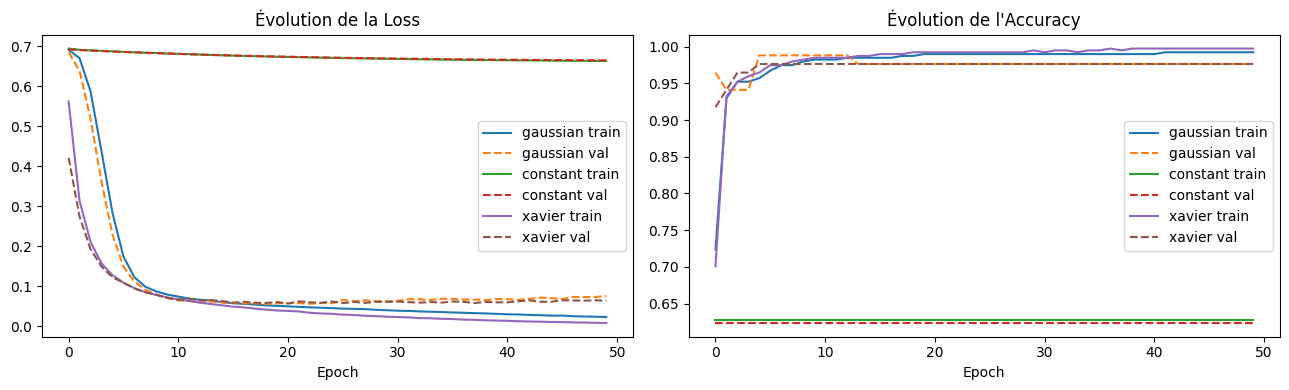


🏆 Meilleure initialisation: gaussian (Val Accuracy: 0.9882)

📊 Métriques sur le Test Set (Meilleur modèle : gaussian)
Accuracy :  0.9186
Precision : 0.9273
Recall    : 0.9444
F1-Score  : 0.9358


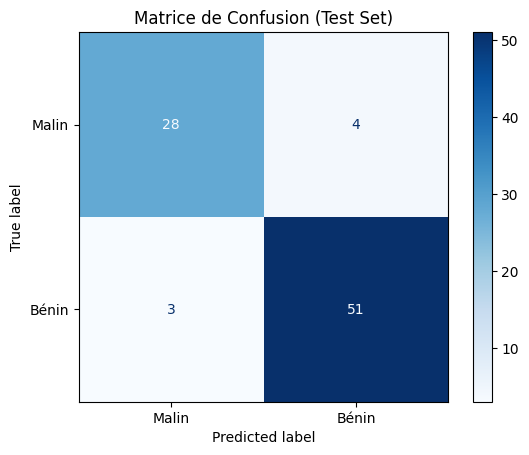

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# (Rappel : assurez-vous que apply_initialization et MLPCustom sont déjà définis dans votre notebook)

def train_model(model, train_loader, val_loader, strategy, epochs=50, lr=1e-3, device=device):
    apply_initialization(model, strategy)
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # 🔹 PHASE ENTRAÎNEMENT
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * X.size(0)
            preds = (torch.sigmoid(out) >= 0.5).float()
            t_correct += (preds == y).sum().item()
            t_total += y.size(0)
        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        
        # 🔹 PHASE VALIDATION
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                loss = criterion(out, y)
                v_loss += loss.item() * X.size(0)
                preds = (torch.sigmoid(out) >= 0.5).float()
                v_correct += (preds == y).sum().item()
                v_total += y.size(0)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        
        # 💾 Sauvegarde du meilleur modèle
        if history["val_acc"][-1] > best_val_acc:
            best_val_acc = history["val_acc"][-1]
            torch.save(model.state_dict(), f"best_mlp_{strategy}.pth")
            
    return history, best_val_acc

# ---------------------------------------------------------
# 1. ENTRAÎNEMENT DES 3 STRATÉGIES
# ---------------------------------------------------------
strategies = ["gaussian", "constant", "xavier"]
all_histories = {}
best_accs = {}

for strat in strategies:
    print(f"🚀 Entraînement avec initialisation: {strat}")
    mlp = MLPCustom(input_dim, 64, output_dim)  # Réutilisation de la classe Étape 2
    hist, acc = train_model(mlp, train_loader, val_loader, strat, epochs=50)
    all_histories[strat] = hist
    best_accs[strat] = acc

# ---------------------------------------------------------
# 2. VISUALISATION DES COURBES D'APPRENTISSAGE
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for strat in strategies:
    axes[0].plot(all_histories[strat]["train_loss"], label=f"{strat} train")
    axes[0].plot(all_histories[strat]["val_loss"], label=f"{strat} val", linestyle="--")
    axes[1].plot(all_histories[strat]["train_acc"], label=f"{strat} train")
    axes[1].plot(all_histories[strat]["val_acc"], label=f"{strat} val", linestyle="--")

axes[0].set_title("Évolution de la Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Évolution de l'Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. ÉVALUATION FINALE SUR LE TEST SET
# ---------------------------------------------------------
best_strategy = max(best_accs, key=best_accs.get)
print(f"\n🏆 Meilleure initialisation: {best_strategy} (Val Accuracy: {best_accs[best_strategy]:.4f})")

# Chargement du meilleur modèle
best_model = MLPCustom(input_dim, 64, output_dim).to(device)
best_model.load_state_dict(torch.load(f"best_mlp_{best_strategy}.pth", map_location=device, weights_only=True))
best_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = best_model(X)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        y_true.extend(y.numpy().flatten())
        y_pred.extend(preds.cpu().numpy().flatten())

print(f"\n📊 Métriques sur le Test Set (Meilleur modèle : {best_strategy})")
print(f"Accuracy :  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malin", "Bénin"])
disp.plot(cmap="Blues")
plt.title("Matrice de Confusion (Test Set)")
plt.show()